# Card Pool EDA

Aggregate stats over the engine's card database (`cg.api.all_card_data()`).
Only counts/distributions are shown here — no individual card names or text are
dumped, per the project's data-redistribution rules (see README “Data & License Notice”).

In [1]:
import sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))

import cg_bridge  # noqa: F401 (adds the vendored cg SDK to sys.path)
from cg_bridge import CardType
from deck import load_card_pool

pool = load_card_pool()
print(f"Total cards: {len(pool)}")

Total cards: 1267


2026-07-06 20:06:26,112 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-06 20:06:26,113 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Pokémon cards: 1056


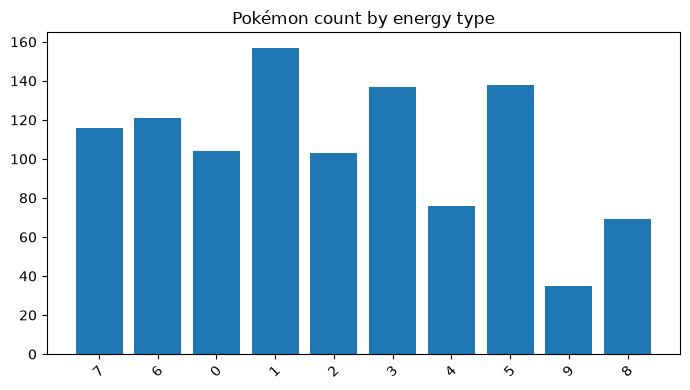

In [2]:
pokemon_cards = [c for c in pool.values() if c.cardType == CardType.POKEMON]
print(f"Pokémon cards: {len(pokemon_cards)}")

energy_counts = Counter(c.energyType for c in pokemon_cards)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(e) for e in energy_counts.keys()], energy_counts.values())
ax.set_title("Pokémon count by energy type")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

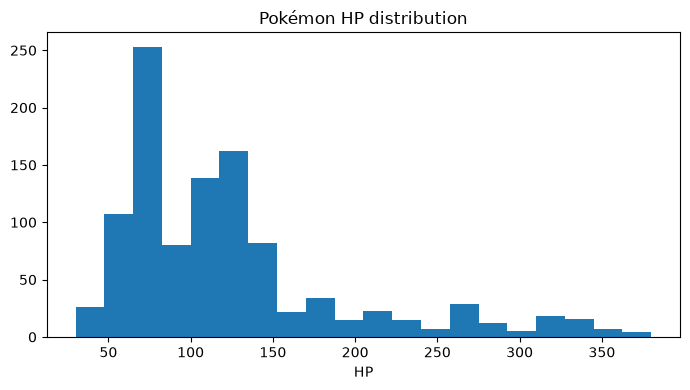

In [3]:
hps = [c.hp for c in pokemon_cards if c.hp]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(hps, bins=20)
ax.set_title("Pokémon HP distribution")
ax.set_xlabel("HP")
plt.tight_layout()
plt.show()

In [4]:
stage_counts = {
    "basic": sum(c.basic for c in pokemon_cards),
    "stage1": sum(c.stage1 for c in pokemon_cards),
    "stage2": sum(c.stage2 for c in pokemon_cards),
    "ex": sum(c.ex for c in pokemon_cards),
    "megaEx": sum(c.megaEx for c in pokemon_cards),
    "tera": sum(c.tera for c in pokemon_cards),
    "aceSpec (any card type)": sum(c.aceSpec for c in pool.values()),
}
stage_counts

{'basic': 595,
 'stage1': 345,
 'stage2': 116,
 'ex': 121,
 'megaEx': 30,
 'tera': 32,
 'aceSpec (any card type)': 29}